In [2]:
import os
import sys
import importlib
import argparse
import math
import numpy as np
import torch
import torchvision
from torchvision.transforms import ToTensor, Compose, Normalize,RandomHorizontalFlip,RandomCrop
from tqdm.notebook import tqdm
import torchshow as ts
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/siddarth/ASSET')

# from model import *
# from utils import setup_seed
from models import *
import new_poi_util as poi_utils
poi_utils = importlib.reload(poi_utils)
from new_poi_util import LocalZipCIFAR10Dataset, my_subset, poi_dataset, set_seed
from new_poi_util import *

torch.cuda.empty_cache()
set_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [3]:
batch_size = 1024
nworkers = 8
valid_size = 1000

In [ ]:
transform = Compose([ToTensor(),])

local_zip = '/home/HDD/ATAF/Datasets/CIFAR10-Dataset/CIFAR-10-60k-targeted.zip'
train_dataset = LocalZipCIFAR10Dataset(local_zip, train=True, transform=None)
val_dataset = LocalZipCIFAR10Dataset(local_zip, train=False, transform=None)

test_dataset = LocalZipCIFAR10Dataset(local_zip, train=False, transform=None)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=nworkers, pin_memory=True)

val_idx = []
for i in range(10):
    current_label = np.where(np.array(val_dataset.targets)==i)[0]
    samples_idx = np.random.choice(current_label, size=int(valid_size/10), replace=False)
    val_idx.extend(samples_idx)

val_set = my_subset(val_dataset, val_idx, transform = transform)   #1000 total images, 100 images per class
# val_set = torchvision.datasets.FakeData(size = 1000, image_size = (3, 32, 32), num_classes = 10, transform = tensor_trans)
meta_dataloader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=True, num_workers=nworkers, pin_memory=True)

# --- pick any poisoning method to test here ---
# POI_METHOD = 'backdoor'                 # visible patch trigger, all2one (target label fixed)
# POI_METHOD = 'backdoor_all2all'         # visible patch trigger, all2all (label = original+1 mod num_classes)
# POI_METHOD = 'noisy_label'              # no trigger, random label noise per class
# POI_METHOD = 'flipping_label'           # no trigger, flips one source class's labels to one target class
# POI_METHOD = 'clean_label_narcissus'    # clean-label attack, noise added to target-class images only
# POI_METHOD = 'noisy_all2one'            # full-image noise trigger, all2one
POI_METHOD = 'noisy_all2all'              # full-image noise trigger, all2all
# POI_METHOD = 'wanet'                    # (ATAF) spatial warp trigger, all2one
# POI_METHOD = 'blended'                  # (ATAF) alpha-blend trigger, all2one
# POI_METHOD = 'badnets'                  # (ATAF) visible patch trigger, all2one
# POI_METHOD = 'low_frequency'            # (ATAF) frequency-domain additive trigger, all2one
# POI_METHOD = 'ssba'                     # (ATAF) sample-specific invisible-style trigger, all2one
# POI_METHOD = 'inputaware'               # (ATAF) sample-specific soft-mask blend trigger, all2one
# POI_METHOD = 'ctrl'                     # (ATAF) clean-label, frequency-domain trigger
TAR_LAB = 2
FLIP_SRC_LAB = 0   # only used when POI_METHOD == 'flipping_label'

THRESHOLD = None    # Put this value as none if you want the best threshold value found in the hyperaparameter sweep, else it loads/trains another model with the given threshold value.
THRESHOLD_BEST = {'backdoor': 1.1, 
                  'backdoor_all2all' : 1.2, 
                  'noisy_label' : 1.8, 
                  'flipping_label' : 1.5, 
                  'clean_label_narcissus' : 1.5,
                  'noisy_all2one': 1.3,
                  'noisy_all2all': 1.1
                  }

if THRESHOLD is None:
    THRESHOLD = THRESHOLD_BEST[POI_METHOD]



MODEL_NAME = 'resnet18_cifar10'

# flipping_label expects tar_lab as (src, dst); every other method expects a single int
tar_lab_arg = (FLIP_SRC_LAB, TAR_LAB) if POI_METHOD == 'flipping_label' else TAR_LAB

# #Delete the train set from dataset
train_poi_set, o_poi_idx = poi_dataset(train_dataset, poi_method=POI_METHOD, transform=transform, poi_rates=0.05,random_seed=0, tar_lab=tar_lab_arg)
train_dataloader = torch.utils.data.DataLoader(train_poi_set, batch_size=batch_size, num_workers=nworkers, pin_memory=True, shuffle=True)

poi_set = Subset(train_poi_set, o_poi_idx)
poi_dataloader = torch.utils.data.DataLoader(poi_set, batch_size=batch_size, num_workers=nworkers, pin_memory=True)

[poi_dataset] Warning: noise file not found at '/home/minzhou/public_html/unlearnable/cifar10/best_universal.npy'. Generating a random placeholder trigger of shape (32, 32, 3) instead. This is NOT the paper's optimized perturbation, so expect a much weaker attack than the original method.


In [5]:
model = ResNet18()
# model.load_state_dict(torch.load('./checkpoint/warmp3_cifar10.pth'))
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
optimizer2 = torch.optim.Adam(model.parameters(), lr=0.0002)

criterion = nn.CrossEntropyLoss()

full_ce = nn.CrossEntropyLoss(reduction='none')
mse = torch.nn.MSELoss()

In [6]:
class HiddenLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(HiddenLayer, self).__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))


class MLP(nn.Module):
    def __init__(self, input_size = 10, hidden_size=100, num_layers=1):
        super(MLP, self).__init__()
        self.first_hidden_layer = HiddenLayer(input_size, hidden_size)
        self.rest_hidden_layers = nn.Sequential(*[HiddenLayer(hidden_size, hidden_size) for _ in range(num_layers - 1)])
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.first_hidden_layer(x)
        x = self.rest_hidden_layers(x)
        x = self.output_layer(x)
        return torch.sigmoid(x)

In [7]:
checkpoint_path = f'/home/HDD/ATAF/siddharth/ASSET/trained_models/poisoned_models/resnet18_cifar10_{POI_METHOD}.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state = checkpoint['state_dict']
else:
    state = checkpoint
o_model = ResNet18()
if isinstance(state, torch.nn.Module):
    o_model = state.to(device)
else:
    o_model.load_state_dict(state)
o_model = o_model.to(device)

In [8]:
o_model.eval()
correct_clean, total_clean = 0, 0
for i, batch in enumerate(poi_dataloader):
    images, labels = batch[0], batch[1]
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        logits = o_model(images)
        out_loss = criterion(logits,labels)
        _, predicted = torch.max(logits.data, 1)
        total_clean += labels.size(0)
        correct_clean += (predicted == labels).sum().item()
acc_clean = correct_clean / total_clean
print('\nASR %.2f' % (acc_clean*100))
print('Test_loss:',out_loss)


ASR 100.00
Test_loss: tensor(0.0001, device='cuda:0')


In [9]:
o_model.eval()
correct_clean, total_clean = 0, 0
idxs = random.sample(range(valid_size), min(batch_size,valid_size))
neg_img = torch.stack([val_set[i][0] for i in idxs]).to(device)
neg_lab = torch.tensor([val_set[i][1] for i in idxs]).to(device)
with torch.no_grad():
    logits = o_model(neg_img)
    out_loss = criterion(logits,neg_lab)
    _, predicted = torch.max(logits.data, 1)
    total_clean += neg_lab.size(0)
    correct_clean += (predicted == neg_lab).sum().item()
acc_clean = correct_clean / total_clean
print('\nClean ACC %.2f' % (acc_clean*100))
print('Test_loss:',out_loss)


Clean ACC 94.10
Test_loss: tensor(0.2106, device='cuda:0')


In [10]:
os.makedirs('/home/HDD/ATAF/siddharth/ASSET/trained_models/asset_best_models', exist_ok=True)
asset_model_path = f'/home/HDD/ATAF/siddharth/ASSET/trained_models/asset_best_models/asset_{MODEL_NAME}_{POI_METHOD}_{THRESHOLD}.pth'

if os.path.exists(asset_model_path):
    print(f'Found existing ASSET-trained model for POI_METHOD={POI_METHOD!r} at {asset_model_path}; loading it instead of retraining.')
    model.load_state_dict(torch.load(asset_model_path, map_location=device))
    model.eval()
else:
    print(f'No saved ASSET-trained model found for POI_METHOD={POI_METHOD!r}; training from scratch.')

    o_model2 = copy.deepcopy(o_model)
    o_model2.linear = nn.Identity()
    model_hat = o_model2.to(device)
    model_hat.eval()
    for p in model_hat.parameters():
        p.requires_grad = False

    for epoch in tqdm(range(2)):
        model.train()

        for iters, batch in enumerate(train_dataloader):
            input_train, target_train = batch[0], batch[1]
            pos_img, pos_lab = input_train.cuda(), target_train.cuda()

            idxs = random.sample(range(valid_size), min(batch_size, valid_size))
            neg_img = torch.stack([val_set[i][0] for i in idxs]).to(device)             # for each iter a 
            neg_lab = torch.tensor([val_set[i][1] for i in idxs]).to(device)

            neg_outputs = model(neg_img)
            neg_loss = torch.mean(torch.var(neg_outputs, dim=1))
            optimizer.zero_grad()
            neg_loss.backward()
            optimizer.step()

            # model_hat is frozen and pos_img/neg_img are fixed for this whole inner loop, so its
            # forward pass is identical every time -- compute it once and reuse, instead of
            # recomputing it 100 times (this does not change any values, only speed).
            with torch.no_grad():
                v_outputs = model_hat(pos_img)
                vn_outputs = model_hat(neg_img)
            feature_dim = v_outputs.shape[1]

            Vnet = MLP(input_size=feature_dim, hidden_size=128, num_layers=2).to(device)
            Vnet.train()
            optimizer_hat = torch.optim.Adam(Vnet.parameters(), lr=0.0001)
            optimizer_hat2 = torch.optim.Adam(Vnet.parameters(), lr=0.0001)

            for _ in range(100):
                vneto = Vnet(v_outputs)
                v_label = torch.ones(v_outputs.shape[0]).to(device)
                rr_loss = mse(vneto.view(-1), v_label)
                Vnet.zero_grad()
                rr_loss.backward()
                optimizer_hat.step()

                vneto2 = Vnet(vn_outputs)
                v_label2 = torch.zeros(vn_outputs.shape[0]).to(device)
                rr_loss2 = mse(vneto2.view(-1), v_label2)
                Vnet.zero_grad()
                rr_loss2.backward()
                optimizer_hat2.step()

            with torch.no_grad():
                res = Vnet(v_outputs)
            '''
            THE ADJUSTED_OUTLYINGNESS FUNCTION CHECKS THE SPREAD OF OUTPUT VALUES FROM MLP AND MEASURES THE DISTANCE
            FROM ITS MEDIAN AND COMPARES IT TO AN ADJUSTED FENCE SET BY A SKEWNESS CHECK USING MEDCOUPLE SCORE
            IF THIS VALUE IS 1, IT IS RIGHT AT THE FENCE, BUT IF IT IS MORE THAN 2, IT IS DOUBLE THE DISTANCE
            BETWEEN MEDIAN AND THE OPTIMIZED FENCE WHICH IS AN INDICATOR THAT THESE IMAGES ARE OUTLIERS (POISONED)

            '''
            
            #was > 2, but not giving good seperation
            pidx = torch.where(adjusted_outlyingness(res) > THRESHOLD)[0]

            if pidx.numel() == 0:
                print(f"Skipping update at iter {iters}: no outliers found")
                continue

            pos_outputs = model(pos_img[pidx])
            real_loss = -criterion(pos_outputs, pos_lab[pidx])
            optimizer2.zero_grad()
            real_loss.backward()
            optimizer2.step()
            print(neg_loss.item(), real_loss.item())

    torch.save(model.state_dict(), asset_model_path)
    print(f'Saved ASSET-trained model to {asset_model_path}')

Found existing ASSET-trained model for POI_METHOD='noisy_all2one' at /home/HDD/ATAF/siddharth/ASSET/trained_models/asset_best_models/asset_resnet18_cifar10_noisy_all2one_1.3.pth; loading it instead of retraining.


In [11]:
poi_res, clean_res = get_result(model, train_poi_set, o_poi_idx)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:05<00:00, 16.63it/s]


0.8543695242105264


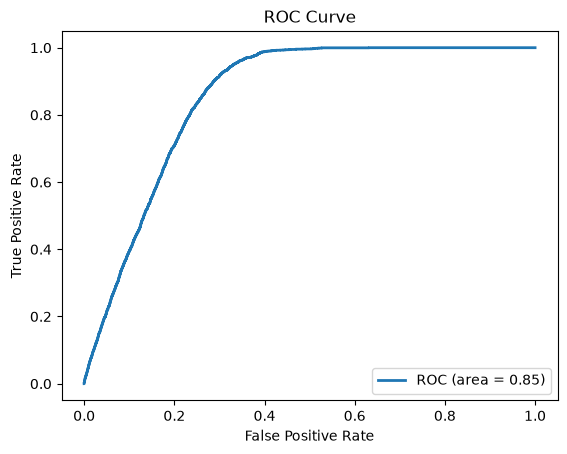

In [12]:
poi_true = [1 for i in range(len(poi_res))]
nor_true = [0 for i in range(len(clean_res))]

true_label = poi_true + nor_true
pred_label = poi_res + clean_res

from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thersholds = roc_curve(true_label, pred_label)
 
roc_auc = auc(fpr, tpr)
print(roc_auc_score(true_label, pred_label))

plt.plot(fpr, tpr, label='ROC (area = {0:.2f})'.format(roc_auc), lw=2)

 
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [13]:
def plot_res(clean_res, poi_res):
    plt.figure(figsize=(3,1.5), dpi=300)
    plt.hist(np.array(clean_res), bins=200,label='Clean', color="#5da1f0")
    plt.hist(np.array(poi_res), bins=200,label='Poison', color="#f7d145")
    # plt.axvline(12.71615742,label='Threshold', color="green")

    # plt.axvline(20,label='Threshold', color="red", lw=0.8, ls='-.')
    plt.ylabel("Number of samples")
    # plt.xlabel("Result")
    plt.xticks([])
    plt.ylim(0, 500)
    plt.ticklabel_format(style='sci',scilimits=(0,0),axis='both')
    # plt.xlim(0, 40)
    plt.legend(prop={'size': 6})
    plt.show()

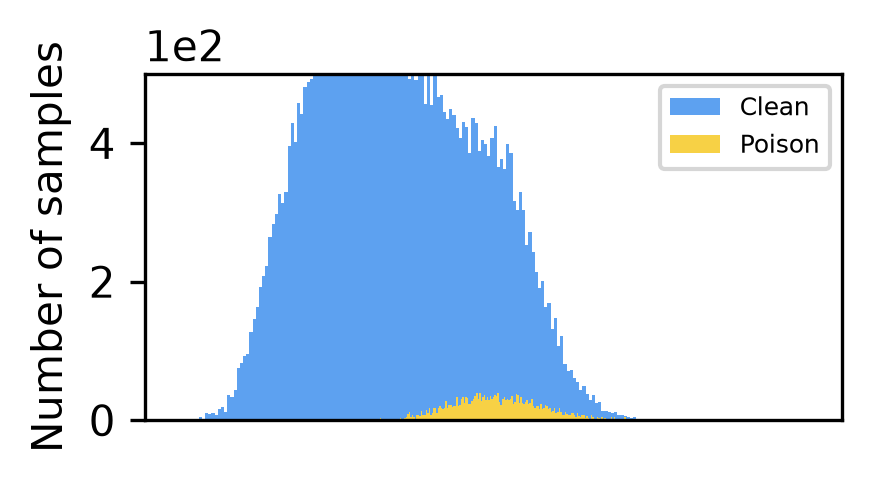

In [14]:
plot_res(clean_res, poi_res)

In [27]:
EPSILON = 5e-23  # (default 1e-6)
total = poi_res + clean_res
t = get_t(total, EPSILON)
print(t)
tp = len(o_poi_idx) - np.where(np.array(poi_res) < t)[0].shape[0]
fp = len(clean_res) - np.where(np.array(clean_res) < t)[0].shape[0]
fn = np.where(np.array(poi_res) < t)[0].shape[0]
print("tp:", tp)
print("fp:", fp)
print("fn:", fn)

[[[2.65181757]]]
tp: 834
fp: 3850
fn: 1666


In [ ]:
import pandas as pd

# Appends this run's results to a persistent CSV so every run (across kernel restarts too)
# stays comparable in one table. Re-run this cell after each experiment to log it.
results_log_path = 'results_csv/asset_results.csv'
os.makedirs('logs', exist_ok=True)
os.makedirs('results_csv', exist_ok=True)

recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
fpr_rate = fp / len(clean_res) if len(clean_res) > 0 else 0.0

new_row = {
    'POI_METHOD': POI_METHOD,
    'Threshold': THRESHOLD,
    'Epsilon': EPSILON,
    'AUC': roc_auc,
    'TP': tp,
    'FP': fp,
    'FN': fn,
    'Recall/TPR': recall,
    'Precision': precision,
    'F1': f1,
    'FPR': fpr_rate,
}

if os.path.exists(results_log_path):
    results_df = pd.read_csv(results_log_path)
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
else:
    results_df = pd.DataFrame([new_row])

results_df.to_csv(results_log_path, index=False)
results_df